In [1]:
import torch
import numpy as np
%matplotlib inline
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import stats, ndimage
from typing import Dict, Any, Tuple, Optional
import pandas as pd
from scipy.ndimage import gaussian_filter1d
from matplotlib.colors import to_rgb
from pathlib import Path
import sys

root = Path().resolve()

sys.path.insert(0, str(root / '../codes'))
from sde_routines_condi import *
from sde_routines import *
from potentials_builder import *
from filters_bank import * 
from utils import *
from utils_entropy import *
from check_moments import *
from potentials import *
from filters import *
from mala import *
from ortho_wavelet import *

sys.path.insert(0, str(root / '../data'))
from data_loader import *

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('device:', device)
print(root)

sys.path.insert(0, str(root / '../turbulence/'))
from diagnostics import * 

device: cuda
/lustre/fswork/projects/rech/wbg/ukv59en/MGD-for-Maximum-Entropy-Generation/jets


In [2]:
# Default parameters
J = 7
Q = 1
M = 128
sigma = 3.5
nt = 10000
n1 = 5000
Re_number = 929
lam = 5e-07

# data preparation 
W = DefineWavelet('Db', m=3, device=device)

Data = load_reynolds_torch(929, device=device)   
print(Data.shape) 

n1_initial = 1024
Data = split_periodize_reshape(Data, n1_initial)

B, C, L = Data.shape
print(Data.shape) 

if M == 128: 
    scales = 3
if M == 256: 
    scales = 2
for j in range(scales):
    Data = W.decompose(Data)[1]

x1 = normalize(Data[:n1]).to(device)

print('x1 shape:', x1.shape)

[load_reynolds] files have different lengths [16695151, 17487491, 17501893, 17506728], truncating all to 16695151
torch.Size([4, 1, 16695151])
torch.Size([65212, 1, 1024])
x1 shape: torch.Size([5000, 1, 128])


In [3]:
# ------------------------------------------------------------------
# Experiment definitions
# ------------------------------------------------------------------
experiments = {
    'phi1,2,4': {
        'label': 'phi1,2,4',
        'name': f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}_nt{nt}_n1_{n1}_{lam}_1_2_4mod2Real',
    },
    'phi1,2,4+L6': {
        'label': 'phi1,2,4+L6', # !!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!!
        'name': f'turbulence_synthesis_{M}_J_{J}_Q_{Q}_sigma_{sigma}_nt{nt}_n1_{n1}_{lam}_1_2_4mod2Real_L6Q1',
   },
}

for key, exp in experiments.items():
    # Check if it's the last experiment and adjust parameters
    #if key == 'GGG':
    #    current_M, current_J = 256, 7
    #else:
    current_M, current_J = M, J
    print(current_M, current_J)
            
    exp['config'] = exp['name']
    print(key, '->', exp['config'])

128 7
phi1,2,4 -> turbulence_synthesis_128_J_7_Q_1_sigma_3.5_nt10000_n1_5000_5e-07_1_2_4mod2Real
128 7
phi1,2,4+L6 -> turbulence_synthesis_128_J_7_Q_1_sigma_3.5_nt10000_n1_5000_5e-07_1_2_4mod2Real_L6Q1


## Thetas 

In [4]:
# 1. Load your experiments as you normally do
results = load_all_experiments(experiments, root, device)

# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, exp in experiments.items():
    theta_t = results[key]['theta_t']
    theta_reg_t = results[key]["theta_reg"]

print(theta_t.shape, theta_reg_t.shape) 

Loading phi1,2,4 ...
Loading phi1,2,4+L6 ...
All experiments loaded.
torch.Size([9959, 79]) torch.Size([48, 79])


In [5]:
theta_reg_t.shape

torch.Size([48, 79])

In [6]:
print(theta_reg_t[:,10]) 

tensor([  -3.3558,    0.7546,   -5.1365,   -2.9775,   -7.9934,   -2.6112,
          -2.4149,   -7.0971,   -1.9083,   -3.7701,   -3.2075,   -6.2670,
          -6.4351,   -8.3067,   -6.1778,   -4.5998,  -11.4982,  -11.6986,
         -10.6467,  -12.6503,  -11.7750,  -17.4925,  -19.4291,  -30.1126,
         -51.3544,  -66.4096,  -91.5494, -106.9800, -130.5564, -153.0466,
        -179.5356, -200.8606, -223.4258, -237.4303, -249.8185, -259.6184,
        -260.4866, -264.6044, -262.9507, -280.1596, -277.7114, -263.6595,
        -281.5705, -270.4684, -262.6307, -276.6405, -268.2095, -249.3883])


In [7]:
final_thetas_reg = theta_reg_t[-1,:]
final_thetas_reg.shape

torch.Size([79])

In [8]:
plt.plot(final_thetas_reg, "o--") 

In [9]:
plt.plot(np.abs(final_thetas_reg[:7]), "o--") 
plt.yscale("log") 

/tmp/xpython_30987/1650455112.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.abs(final_thetas_reg[:7]), "o--")


In [10]:
plt.plot(np.abs(final_thetas_reg[:7]), "o--") 
plt.yscale("log") 

/tmp/xpython_30987/1650455112.py:1: DeprecationWarning: __array_wrap__ must accept context and return_scalar arguments (positionally) in the future. (Deprecated NumPy 2.0)
  plt.plot(np.abs(final_thetas_reg[:7]), "o--")


## Optionally coarse grain and compute diagnostics 

Loading phi1,2,4 ...
Loading phi1,2,4+L6 ...
All experiments loaded.
torch.Size([5000, 1, 128])
torch.Size([5000, 1, 128])
Marginal histograms


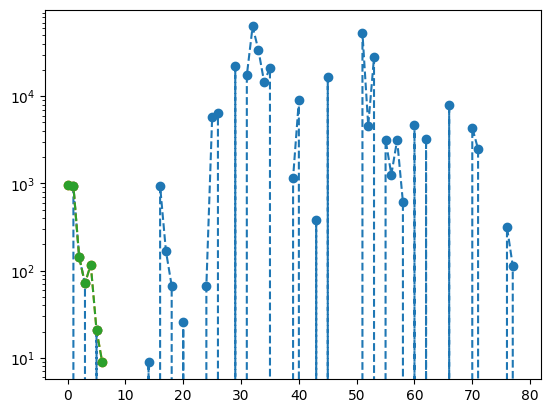

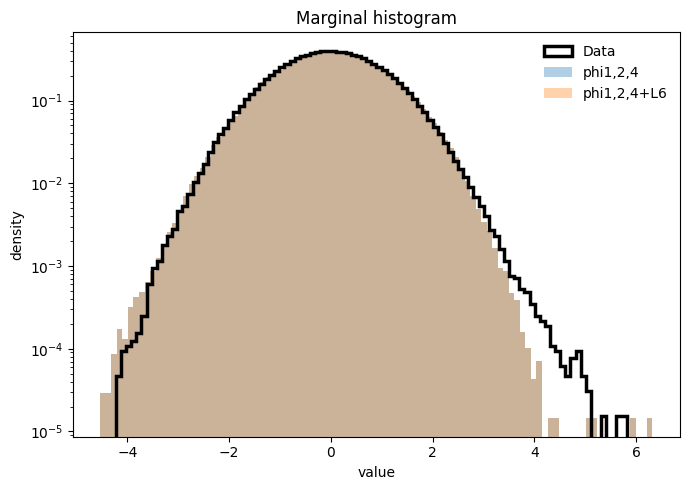

Per-band wavelet histograms (Q=1)


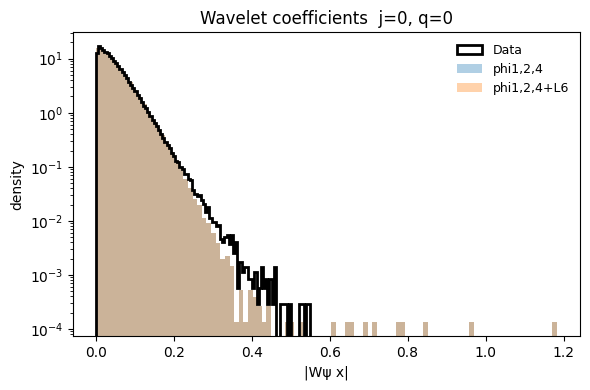

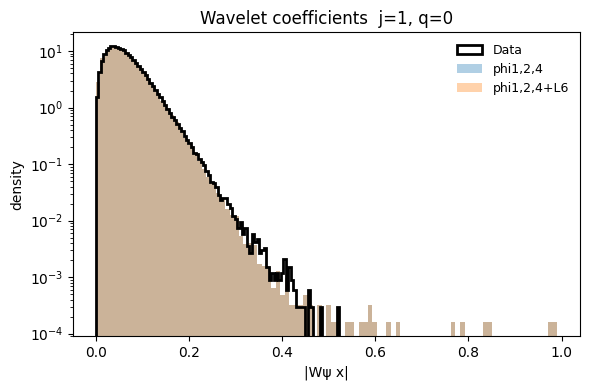

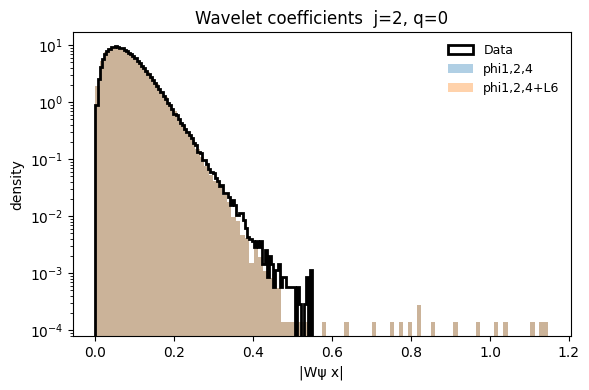

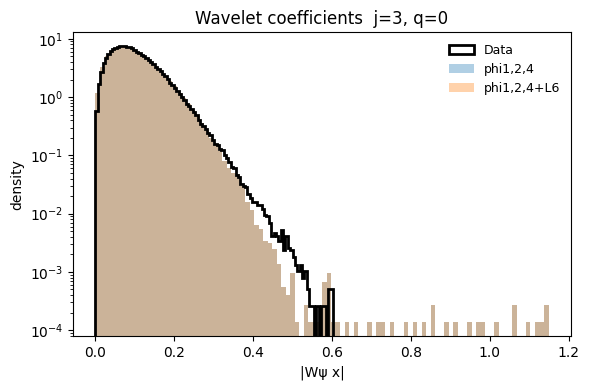

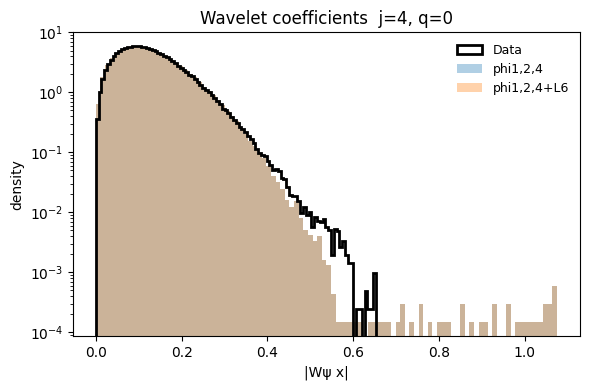

Moment matching


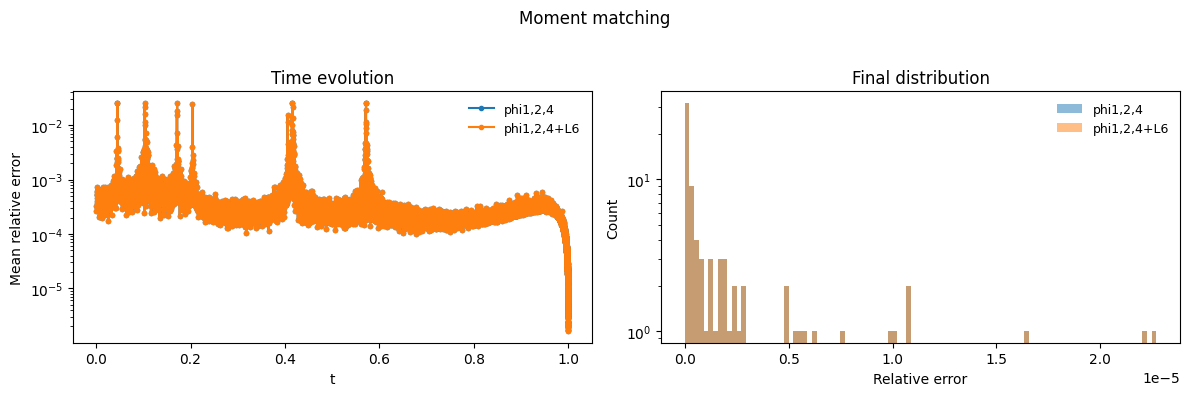

Power spectra


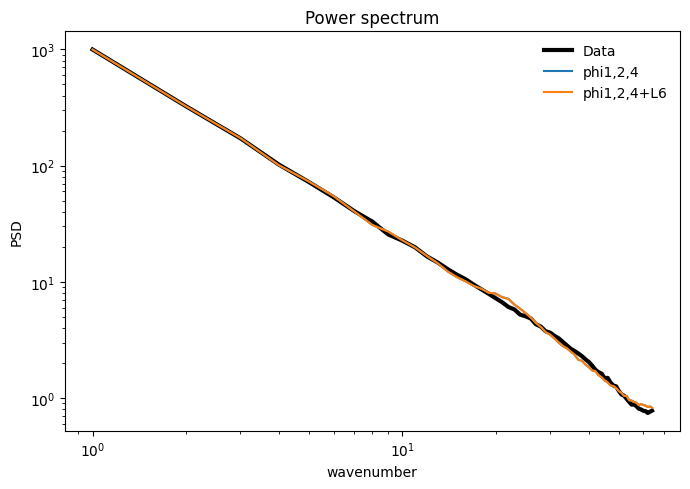

Structure functions


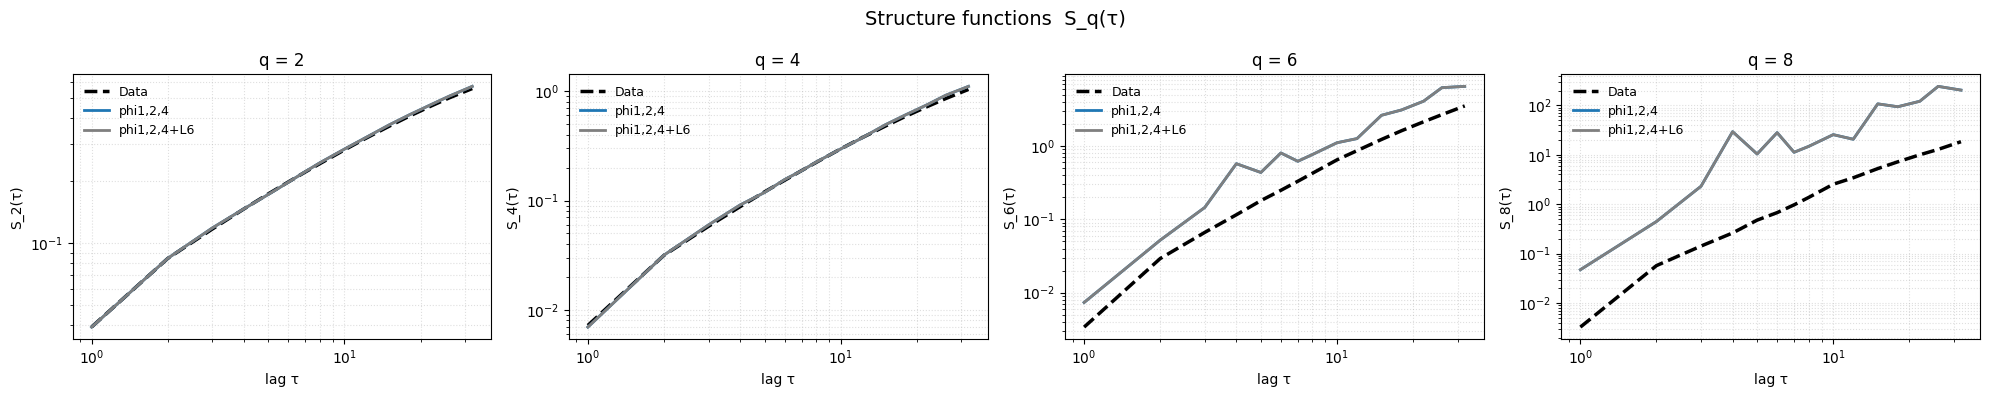

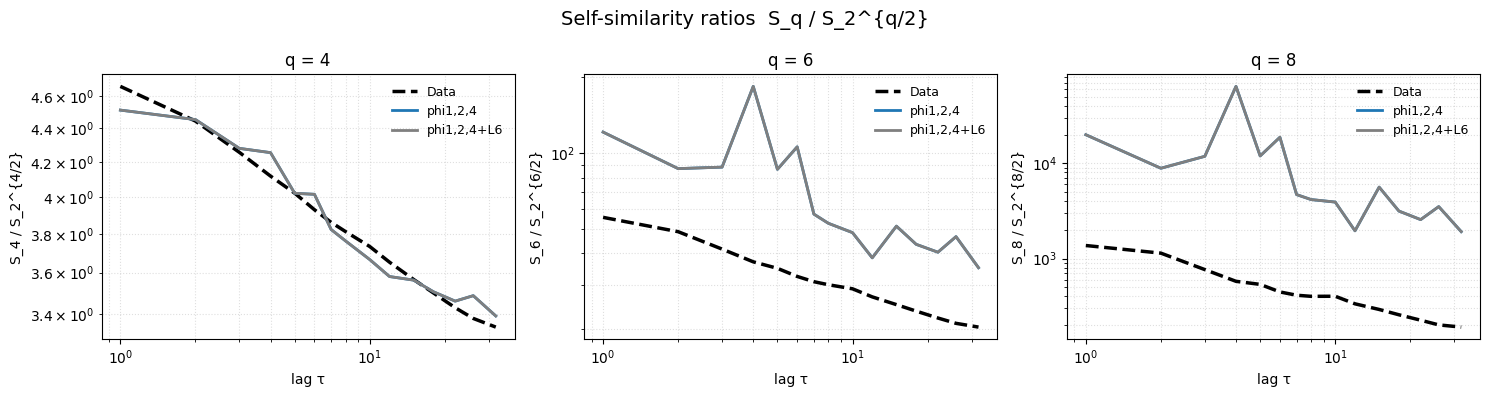

Increment PDFs


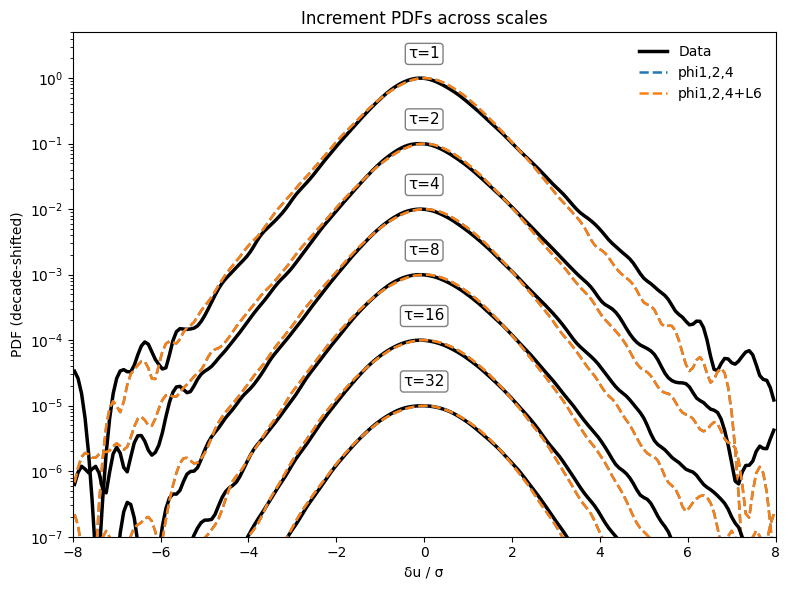

Cross structure functions


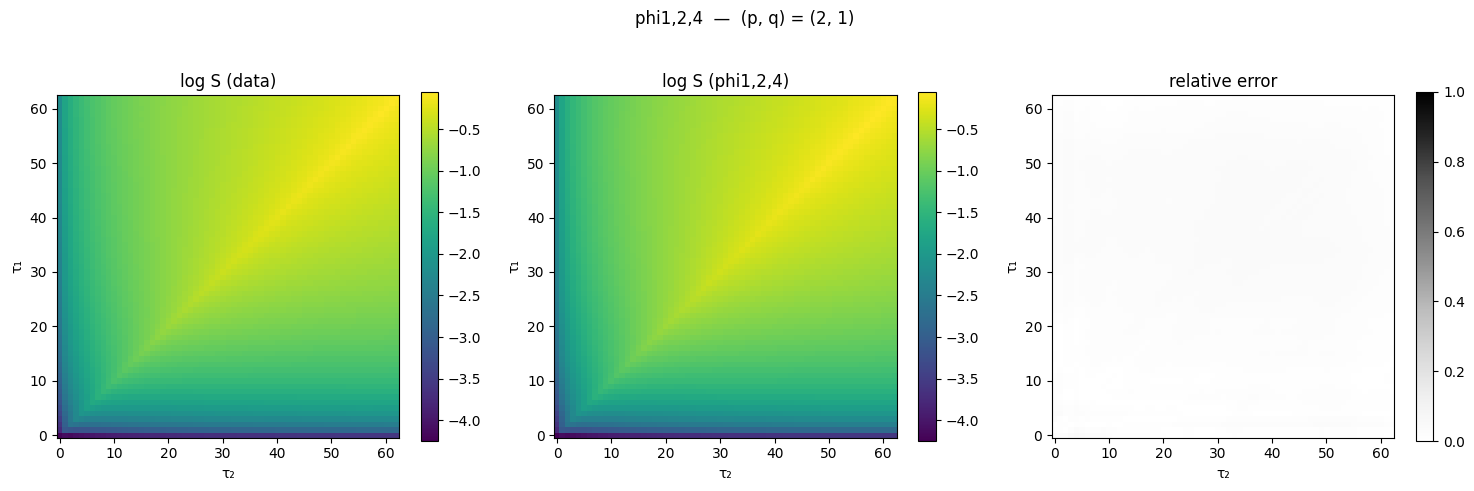

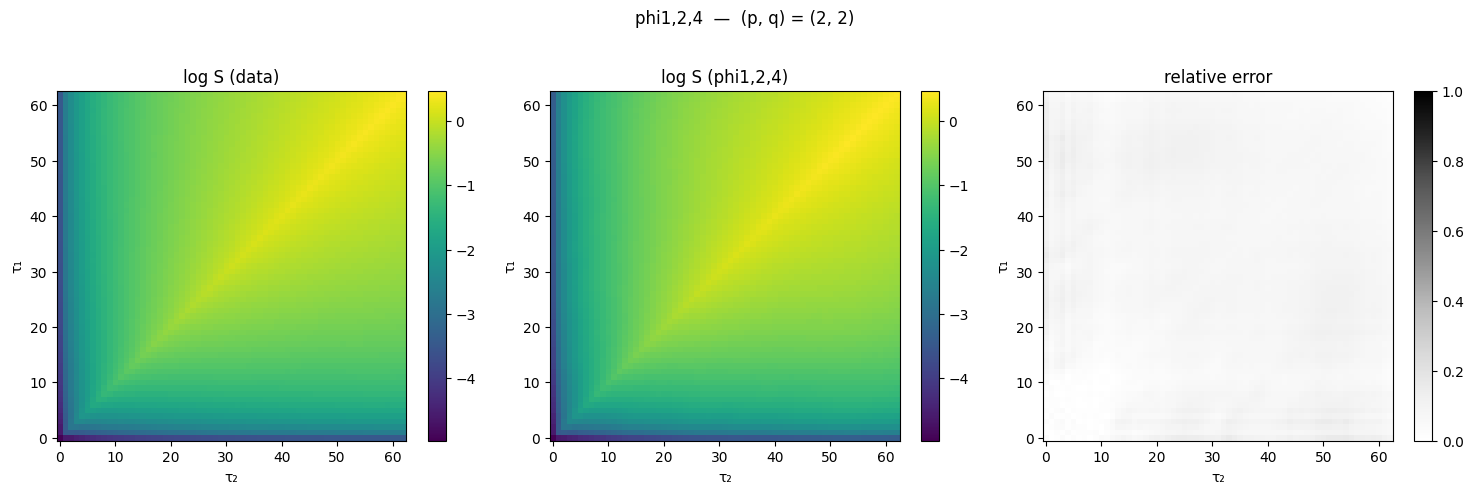

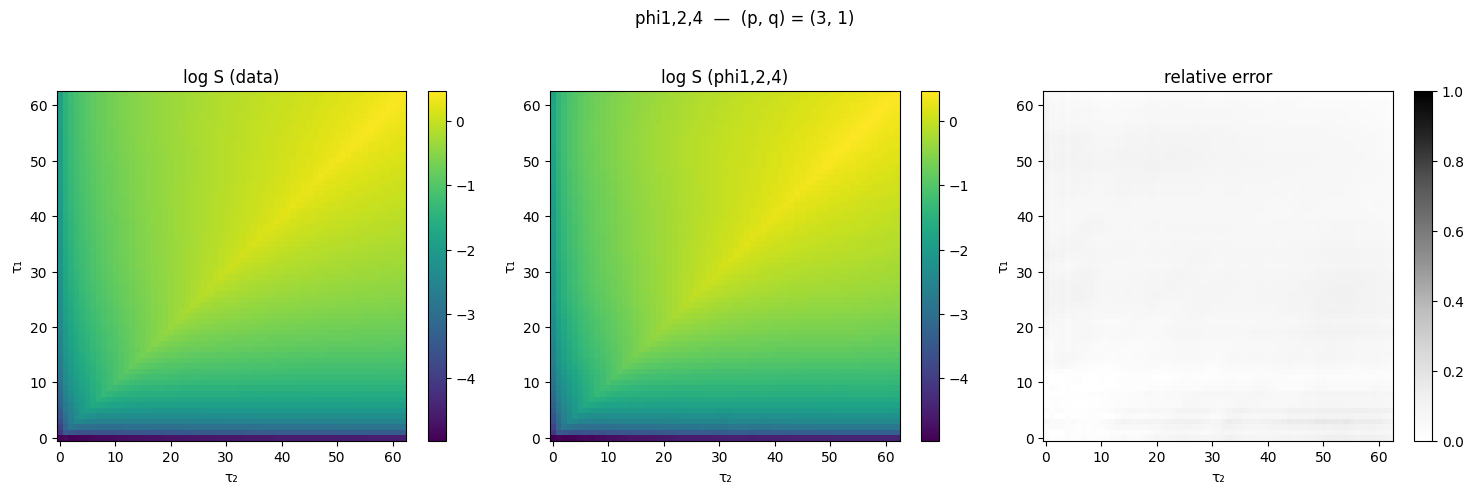

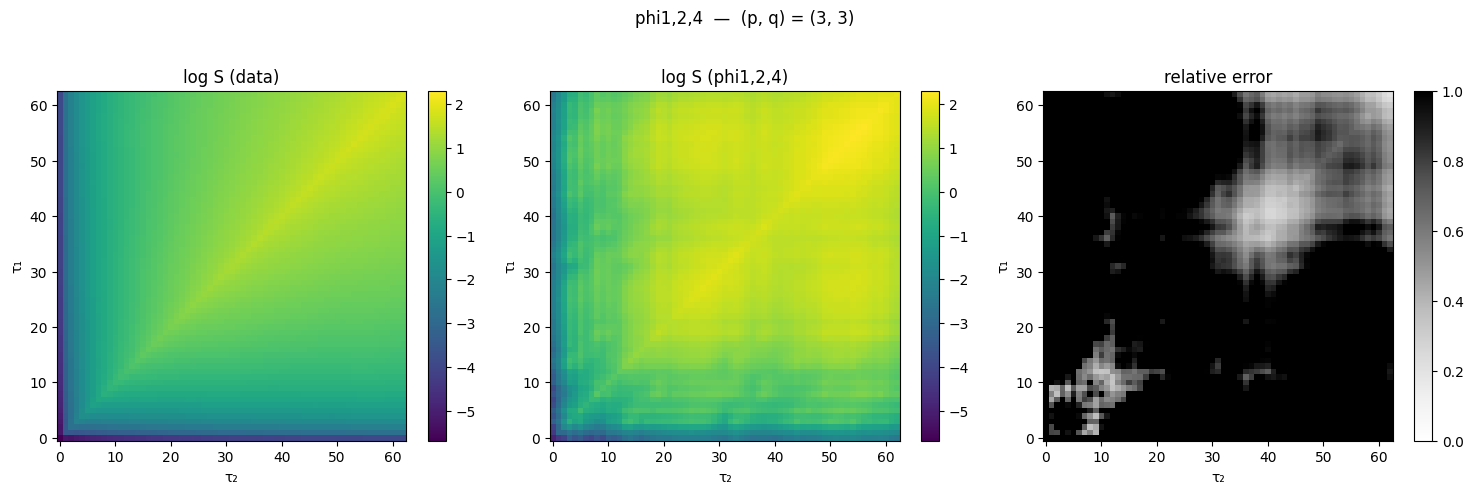

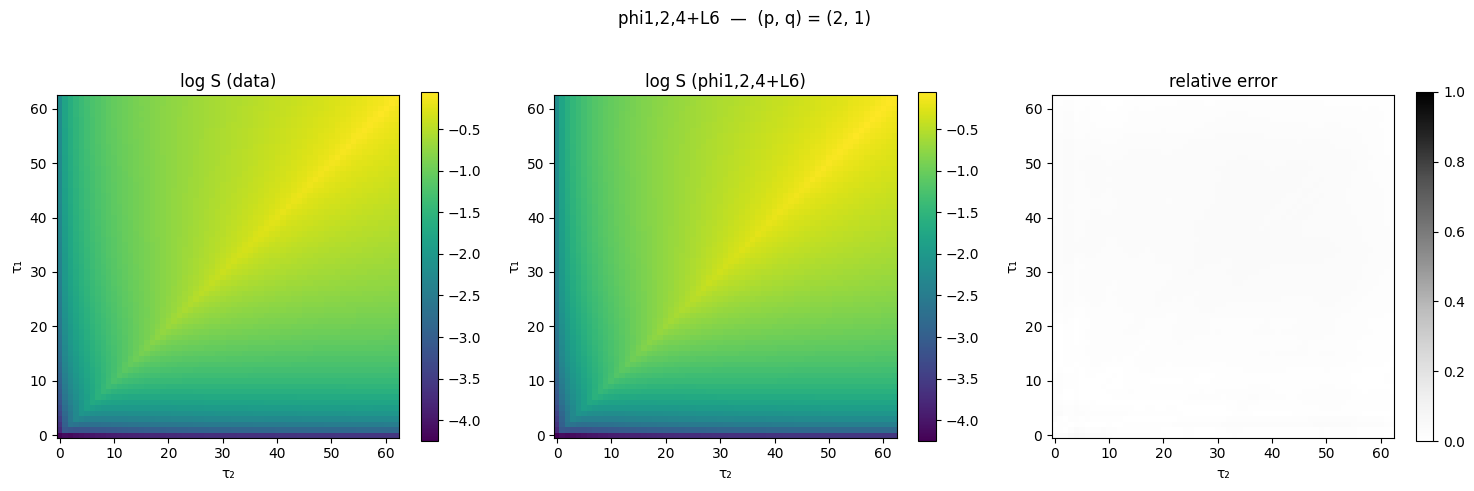

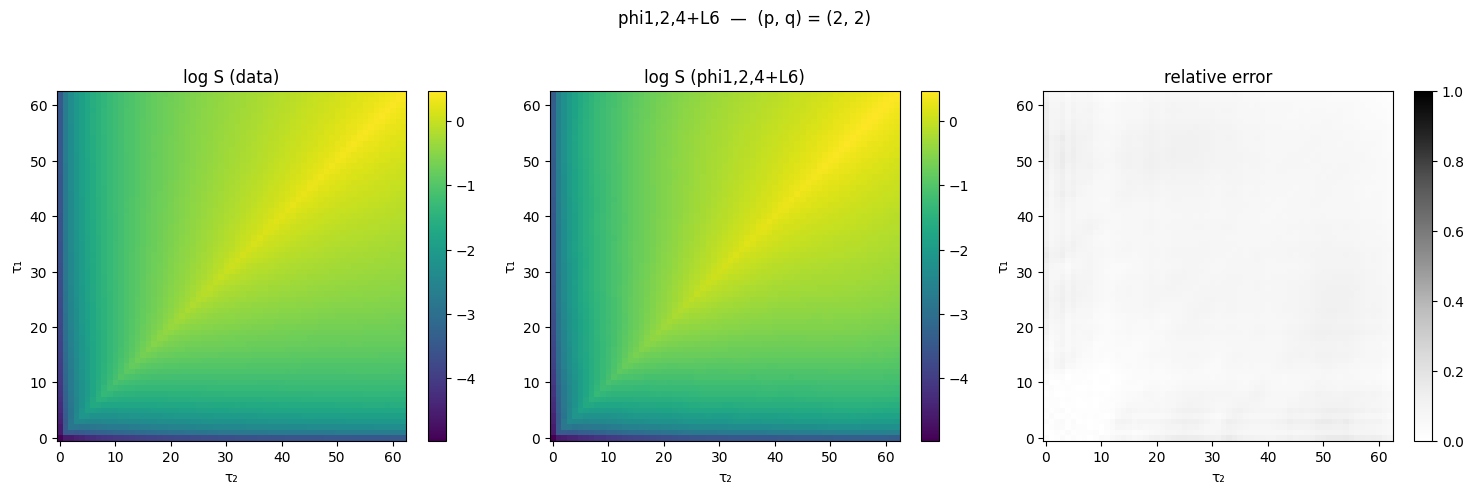

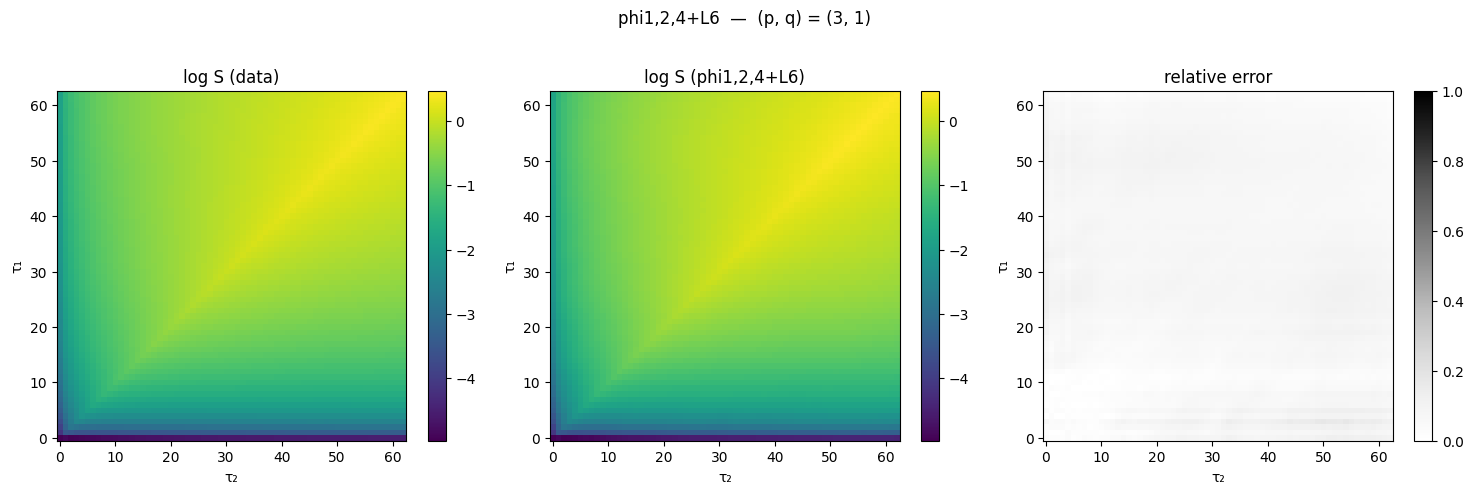

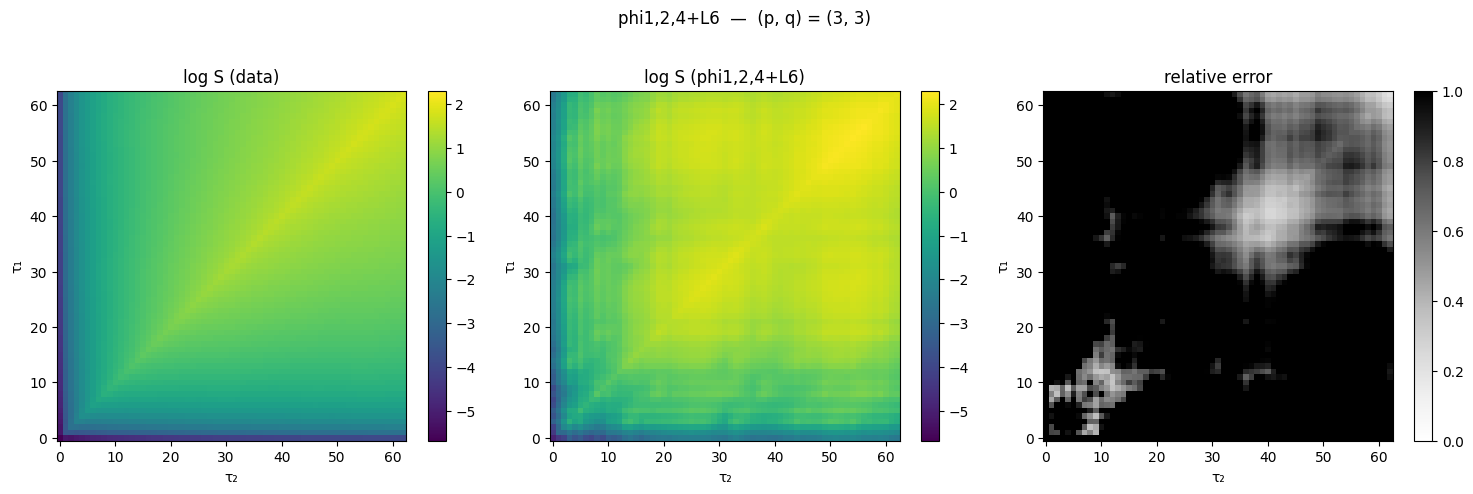

Entropy bound
phi1,2,4:
  Entropy bound: -2545.2183
  Gaussian estimation: -14.7053
phi1,2,4+L6:
  Entropy bound: -2545.2183
  Gaussian estimation: -14.7053


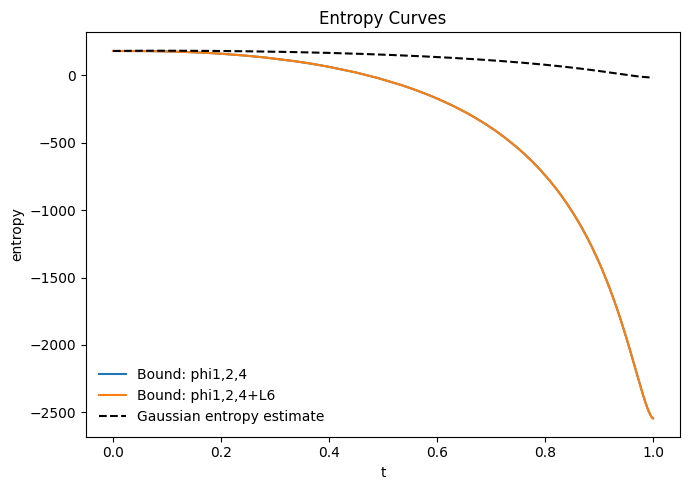

Entropy bound evolution (per experiment)


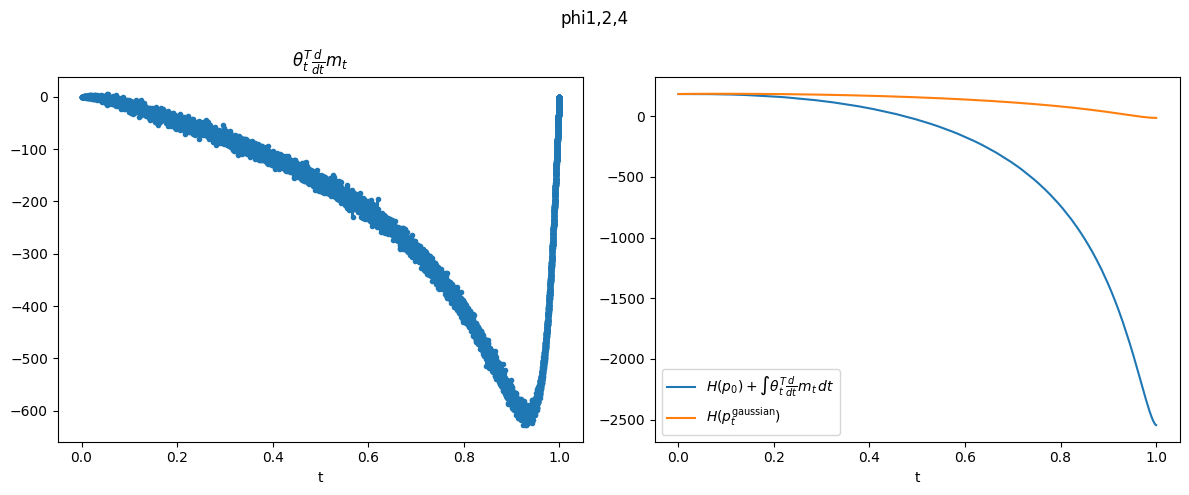

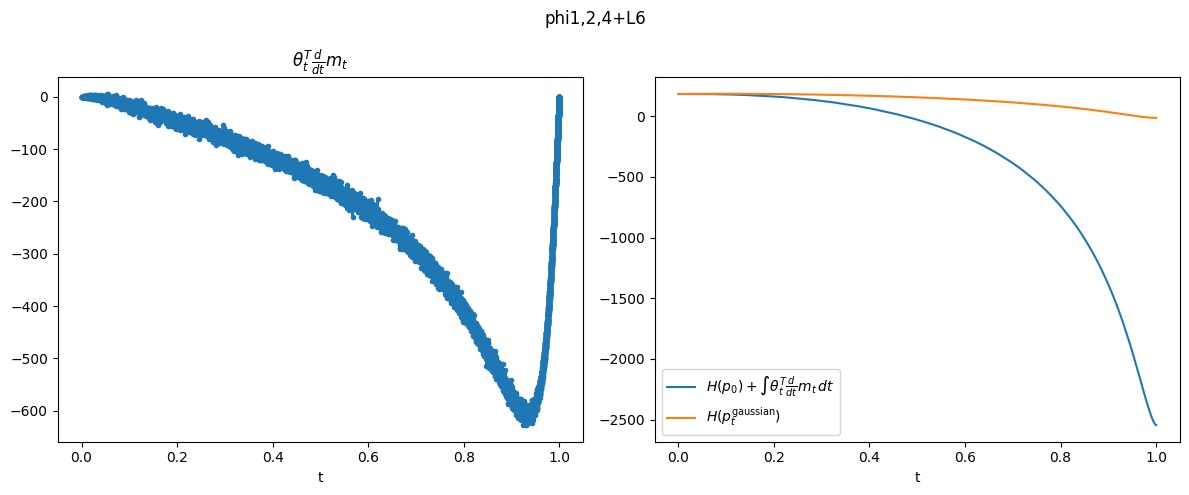

Visual comparison panels


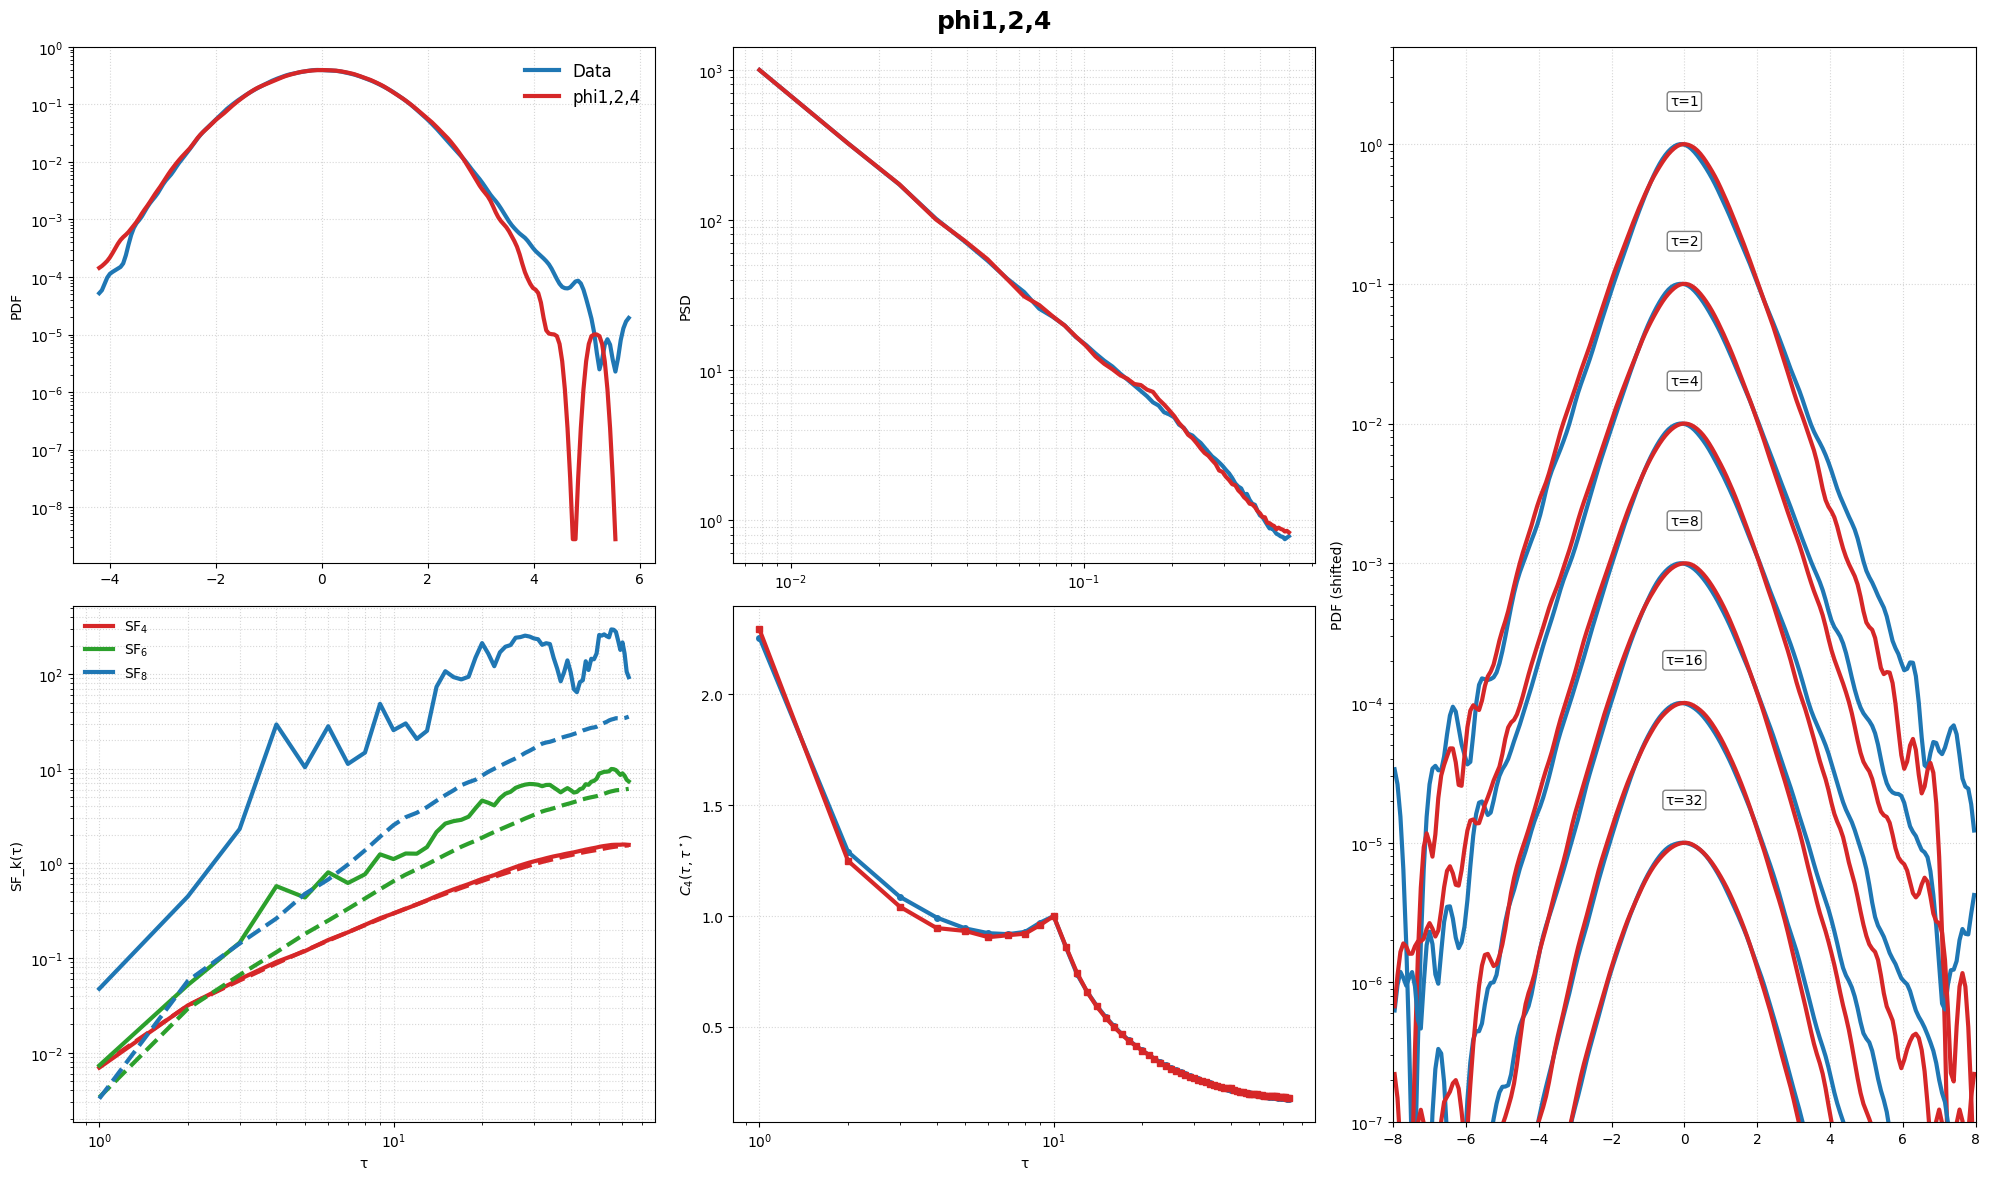

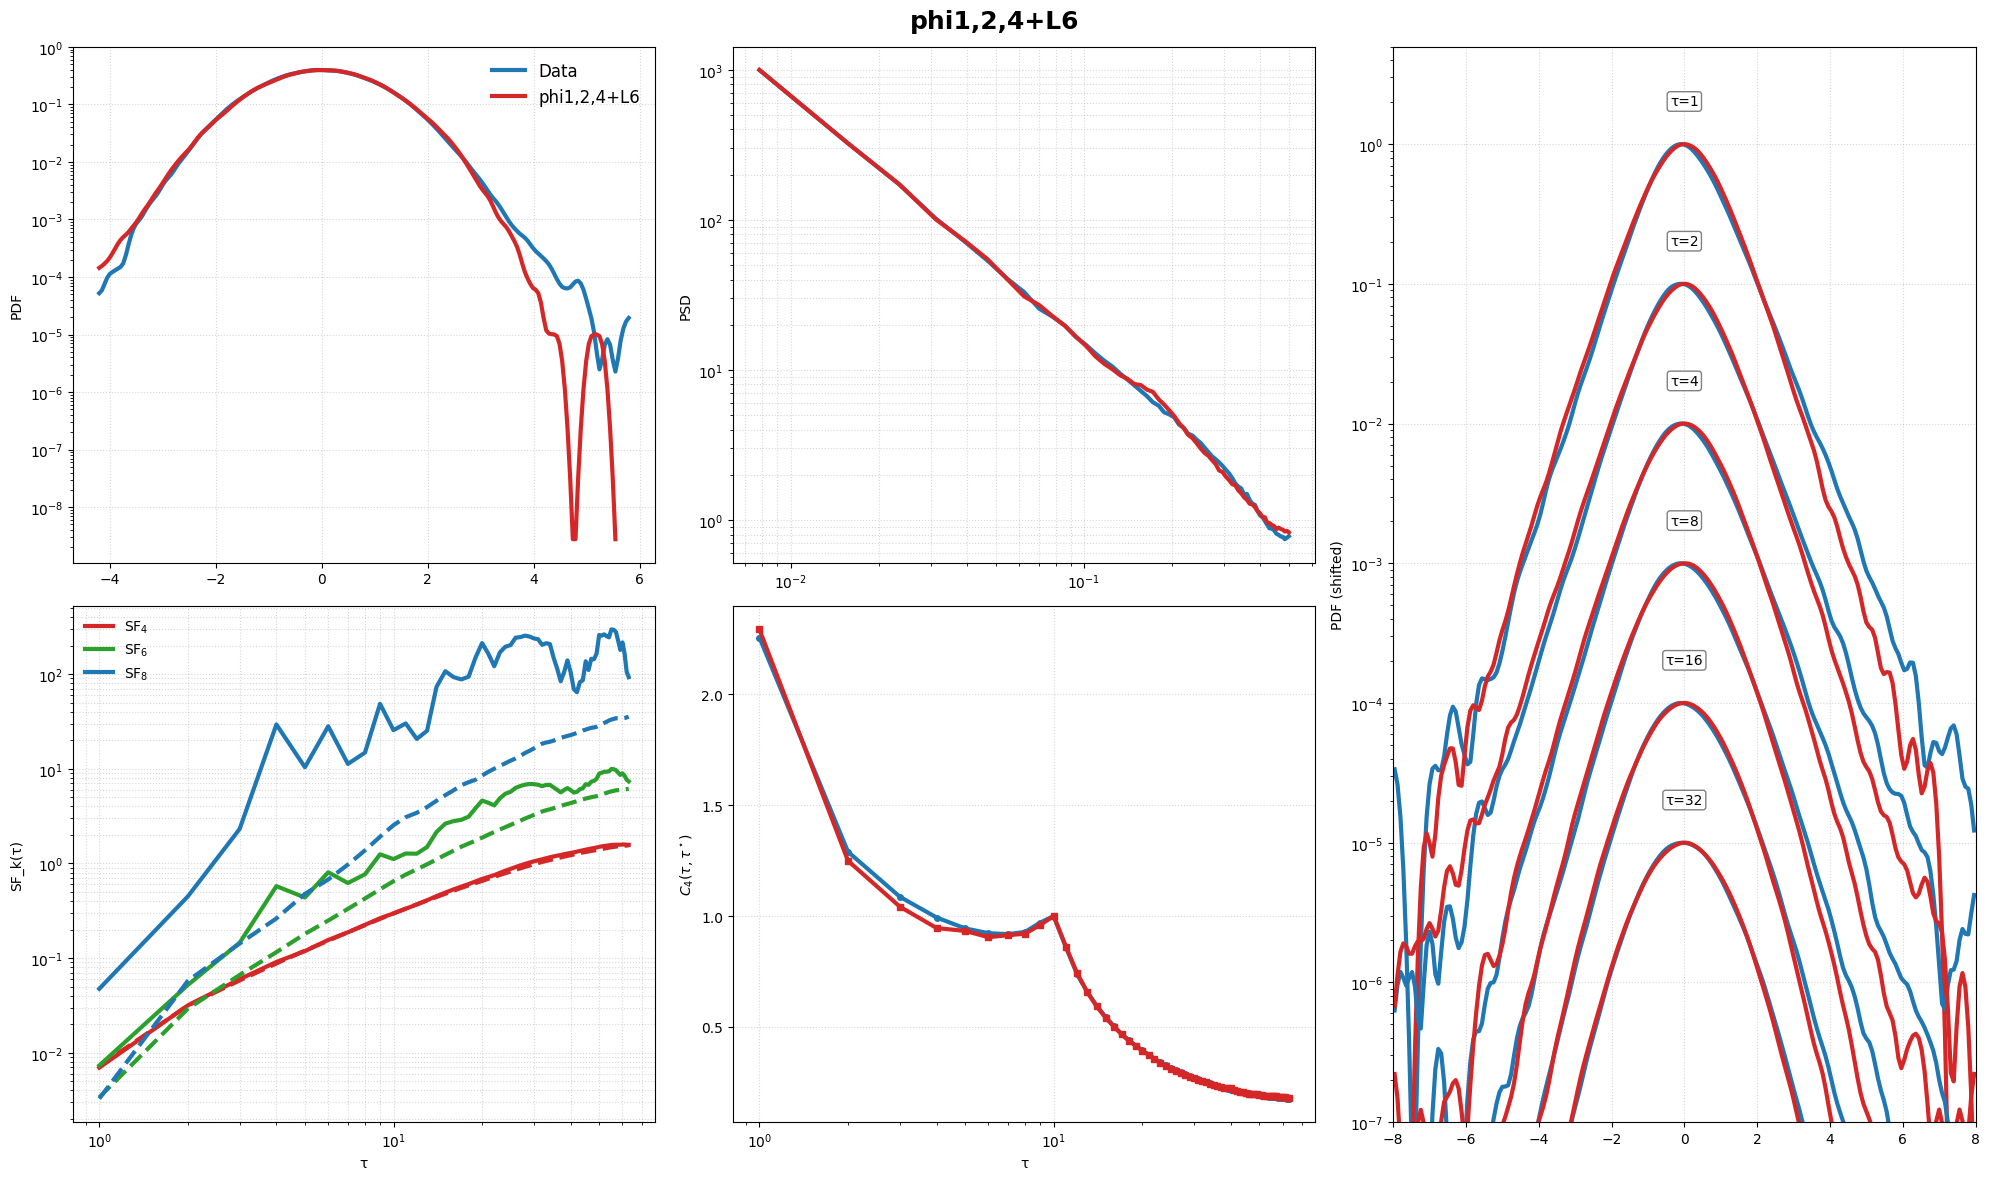

Scalar metrics
             mean_rel_error  std_rel_error  spectrum_rel_mse  wasserstein_mean  structure_rel_mse
phi1,2,4       368023.40625       0.000033      1.018246e-07          0.011125           0.001295
phi1,2,4+L6    368023.40625       0.000033      1.018246e-07          0.011125           0.001295


In [11]:
# 1. Load your experiments as you normally do
results = load_all_experiments(experiments, root, device)

# 2. Coarse-grain only the experiments that have M=256 (length 256)
for key, exp in experiments.items():
    xt = results[key]['xt']
    print(xt.shape) 
%matplotlib inline
df = run_diagnostics(
    x1, results, experiments,
    Q=1,                          # or 3, matches your wavelet config
    show_wavelet_histograms=True,
    complex_wavelet_histograms=False,  # True -> real/imag split instead of |.|
    show_entropy_detail=True,
)



## Negentropy time=1

In [14]:
import re

def _sigma_from_label(label: str) -> float:
    """Extract the numeric sigma value from a label like 'sigma = 20.0'."""
    m = re.search(r'sigma\s*=\s*([0-9.]+)', label)
    if m is None:
        raise ValueError(f"Could not parse sigma from label: {label!r}")
    return float(m.group(1))



def _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point):
    """Final-time entropy bound H_sigma* = H(p_0) + cumulative integral of dH."""
    dH_t_bound = dH_t_bound.detach().cpu()
    t_used = t_used.detach().cpu()
    nt_val = nt if nt is not None else t_used.shape[0]

    d = x_ref.shape[-2] * x_ref.shape[-1]
    H_p_0 = (np.log(2 * np.pi) + 1) * d / 2
    H_t_bound_full = dH_t_bound.cumsum(0) / nt_val + H_p_0

    # Guard against dH_t_bound/t length mismatch (same issue as plot_entropy_curves)
    min_len = min(t_used.shape[0], H_t_bound_full.shape[0])
    H_final = H_t_bound_full[min_len - last_point].item()
    return H_p_0, H_final, d


def plot_negentropy_convergence(
    x_ref: torch.Tensor,
    results: Dict[str, Dict],
    experiments: Dict[str, Dict],
    last_point=1,
    nt: Optional[int] = None,
) -> pd.DataFrame:
    """
    Reproduce Fig. 7 style plots across a sweep of sigma experiments:
      (a) ΔH_σ* = H(p_0) - H_σ*         vs sigma^2
      (b) d^-1 (H_σmax* - H_σ*)         vs sigma^2, log-log, with sigma^-2 reference
    Requires >=2 experiments, each with a 'sigma = <value>' label.
    """
    sigmas, H_finals, ds = [], [], []
    H_p_0 = None
    for key, exp in experiments.items():
        sigma_val = _sigma_from_label(exp["label"])
        t_used = results[key]['t']
        dH_t_bound = results[key]['dH_t_bound']
        print(dH_t_bound) 
        H_p_0, H_final, d = _entropy_bound_beforefinal(x_ref, dH_t_bound, t_used, nt, last_point)
        sigmas.append(sigma_val)
        H_finals.append(H_final)
        ds.append(d)

    sigmas = np.array(sigmas)
    H_finals = np.array(H_finals)
    d = ds[0]  # assumes same dimensionality across all experiments

    order = np.argsort(sigmas)
    sigmas, H_finals = sigmas[order], H_finals[order]
    sigma2 = sigmas ** 2
    negentropy = H_p_0 - H_finals

    # Reference run: largest sigma in the sweep
    idx_max = np.argmax(sigmas)
    H_max = H_finals[idx_max]
    conv = np.abs(H_max - H_finals) / d

    fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

    # (a) negentropy vs sigma^2
    axes[0].plot(sigma2, negentropy, 'o--', color='tab:blue')
    axes[0].set_xlabel(r'$\sigma^2$')
    axes[0].set_ylabel(r'$\Delta H_*^\sigma$')
    axes[0].set_title('Negentropy estimate')
    axes[0].grid(True, ls=':', alpha=0.4)

    # (b) convergence vs sigma_max, log-log (drop the sigma_max point: diff = 0)
    mask = np.arange(len(sigmas)) != idx_max
    axes[1].loglog(sigma2[mask], conv[mask], 'o', color='tab:blue', label='data')

    x_line = np.geomspace(sigma2[mask].min(), sigma2[mask].max(), 50)
    c = conv[mask][0] * sigma2[mask][0] ** 2  # anchor sigma^-2 line to first point
    #axes[1].plot(x_line, c / x_line ** 2, '-', color='tab:blue',linewidth=1.5, label=r'$\sigma^{-2}$')

    axes[1].set_xlabel(r'$\sigma^2$')
    axes[1].set_ylabel(r'$d^{-1}(H_*^{\sigma_{\max}} - H_*^\sigma)$')
    axes[1].set_title(fr'Convergence ($\sigma^2_{{\max}}$={sigma2[idx_max]:.2g})')
    axes[1].legend(frameon=False, fontsize=9)
    axes[1].grid(True, which='both', ls=':', alpha=0.4)

    plt.tight_layout()
    plt.show()

    return pd.DataFrame({
        'sigma': sigmas, 'sigma2': sigma2,
        'H_final': H_finals, 'negentropy': negentropy,
        'convergence': conv,
    })

Loading sigma = 0.1 ...
Loading sigma = 1 ...
Loading sigma = 2.0 ...
Loading sigma = 3.5 ...
Loading sigma = 10.0 ...
Loading sigma = 20.0 ...
Loading sigma = 50.0 ...
All experiments loaded.
tensor([  19.9041,   -8.5011,    4.0480,  ..., -110.5010, -183.5685,
              nan])
tensor([  0.1779,  -0.2589,   1.0279,  ..., -14.4276,  -4.5941,      nan])
tensor([  0.3081,   0.1437,   0.7971,  ..., -12.3267,   5.9603,      nan])
tensor([ 0.4048,  0.3124,  0.6997,  ..., -8.8481, -5.0666,     nan])
tensor([0.4400, 0.3886, 0.5794,  ...,    nan,    nan,    nan])
tensor([0.4446, 0.4189, 0.5314,  ...,    nan,    nan,    nan])
tensor([0.4042, 0.3960, 0.4296,  ...,    nan,    nan,    nan])


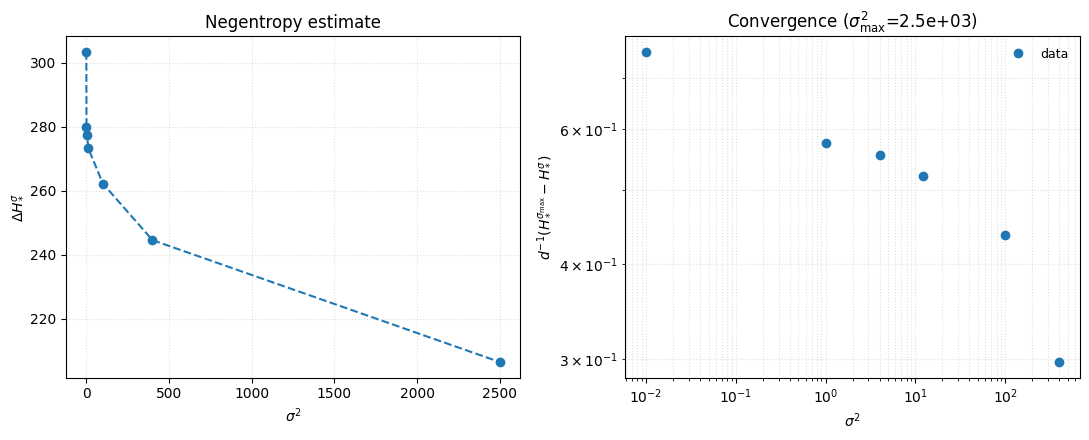

,sigma,sigma2,H_final,negentropy,convergence
0,0.1,0.01,-121.804642,303.428774,0.756853
1,1.0,1.00,-98.493546,280.117678,0.574735
2,2.0,4.00,-95.924484,277.548617,0.554664
3,3.5,12.25,-91.696457,273.320589,0.521632
4,10.0,100.00,-80.676285,262.300417,0.435537
5,20.0,400.00,-63.008774,244.632906,0.297510
6,50.0,2500.00,-24.927505,206.551638,0.000000


In [18]:
# experiments = {
#     f'sigma_{s}': {
#         'label': f'sigma = {s}',
#         'config': f'jetsynth_Re_number{Re_number}_M{M}_J{J}_Q{Q}_sigma{s}_nt10000_n1_{n1}_lam{lam}',
#     }
#     for s in [0.1, 1.0, 2.0, 3.5, 10.0]
# }

experiments = experiments
results = load_all_experiments(experiments, root, device)
df = plot_negentropy_convergence(x1, results, experiments, last_point=50)
df

## Theta scaling 

In [36]:
# ----------------------------------------------------------------------
# Terms used to build the potentials. Not stored in `exp`, so given
# explicitly here (must match what was actually used to run the SDE for
# these experiments -- if different experiments used different TERMS,
# this needs to move inside analyze_experiment and be looked up per key
# instead of being global).
# ----------------------------------------------------------------------
TERMS = (
    'Scattering_First_Order',
    'Scattering_Second_Order',
    'Scattering_Fourth_Order_Mod2_Real_Q1',
)

In [37]:
filters = return_Filters(M, J, 1, device=device)

Loading sigma = 3.5 ...
All experiments loaded.
sigma = 3.5 -> theta_t (19961, 71)  theta_reg_t (98, 71)
theta_reg length per experiment: {'sigma = 3.5': 98}
Not M=256, excluded from any cross-experiment pooling: ['sigma = 3.5']
Comparable experiments (M == 256): []
Analysing experiment: sigma = 3.5
potential                             dim            cols  source
Scattering_First_Order                  7  [   0:7   ]  'num_coefficients' attribute
Scattering_Second_Order                 8  [   7:15  ]  'num_coefficients' attribute
Scattering_Fourth_Order_Mod2_Real_Q1    56  [  15:71  ]  'num_coefficients' attribute
OK: 3 potentials account for all 71 theta_reg columns.
-> Scattering_Fourth_Order_Mod2_Real_Q1: cols [15:71] out of 71
scat_potential.J = 7  Q = 1  num_coefficients = 56
-> row 0 matches the combinatorial fingerprint for j exactly.
non-finite count per column: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0]
r

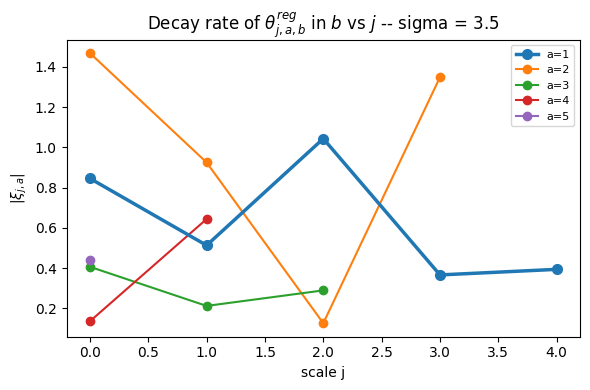

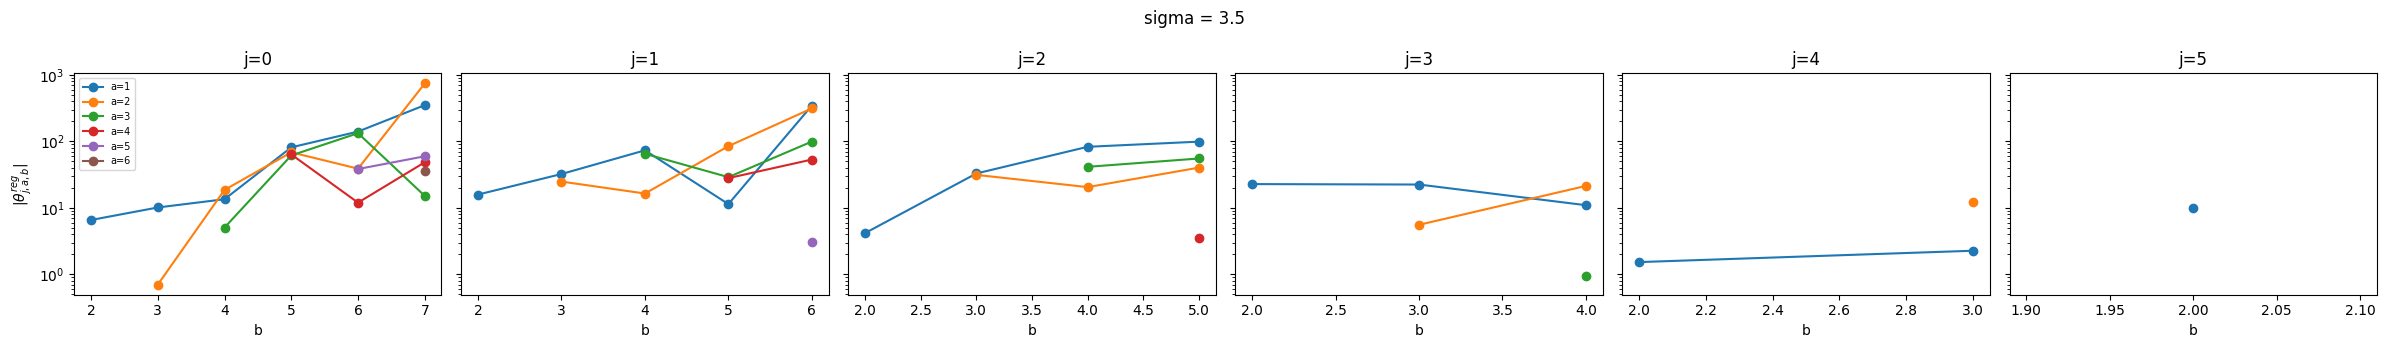

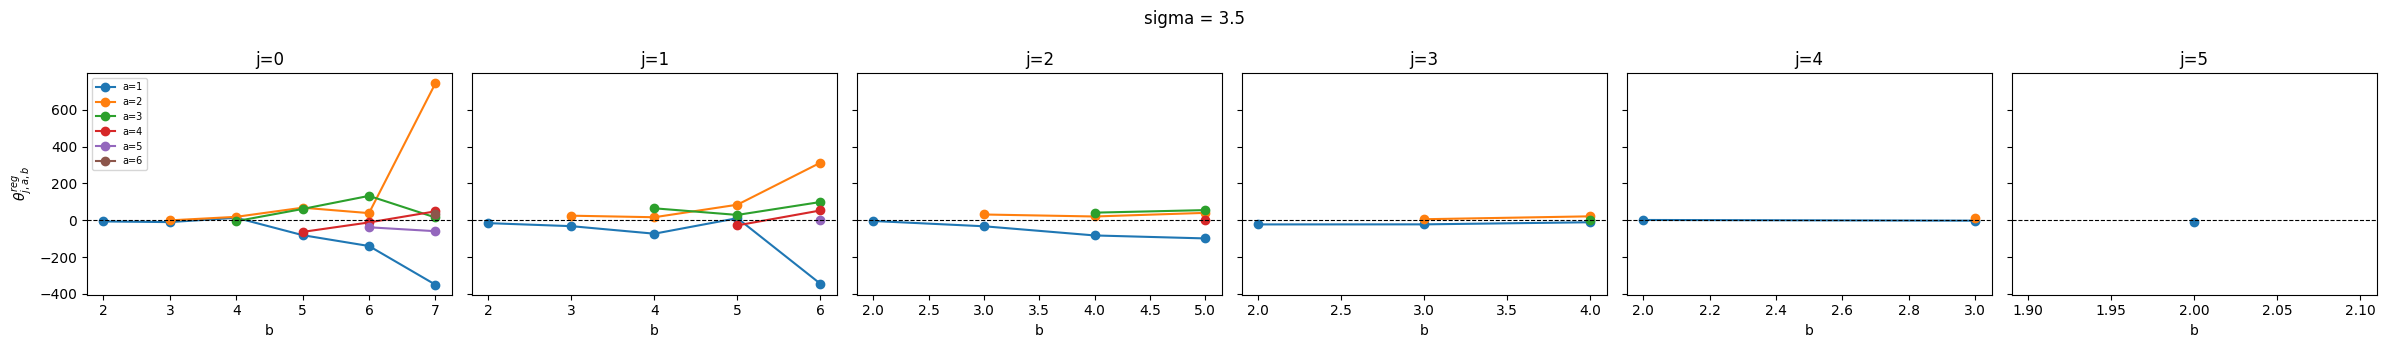

In [38]:
## Scattering theta_reg scaling analysis

# ----------------------------------------------------------------------
# Load everything up front (as in your loading cells).
# ----------------------------------------------------------------------
results = load_all_experiments(experiments, root, device)

for key, exp in experiments.items():
    theta_t     = results[key]['theta_t']
    theta_reg_t = results[key]['theta_reg']
    print(key, '-> theta_t', tuple(theta_t.shape), ' theta_reg_t', tuple(theta_reg_t.shape))

# ----------------------------------------------------------------------
# 2. Only pool/compare experiments that share the same coarse-grid
#    length M. theta_reg's row count depends on how many nodes survived
#    _cut_close_time_nodes, which varies per experiment.
# ----------------------------------------------------------------------
M_target = 256
experiment_lengths = {k: results[k]['theta_reg'].shape[0] for k in experiments}
print("theta_reg length per experiment:", experiment_lengths)

comparable_keys = [k for k, n in experiment_lengths.items() if n == M_target]
skipped_keys    = [k for k, n in experiment_lengths.items() if n != M_target]
if skipped_keys:
    print(f"Not M={M_target}, excluded from any cross-experiment pooling: {skipped_keys}")
print(f"Comparable experiments (M == {M_target}): {comparable_keys}")

from collections import defaultdict
import math

TARGET_KEY = 'Scattering_Fourth_Order_Mod2_Real_Q1'
KNOWN_POTENTIAL_DIMS = {
    'L_2_lowpass': 1,
    'Scattering_Fourth_Order_Mod2_Real_Q1': 84,
    'Scalar_psi_coshgt': 50,
    'Scalar_morlet_coshgt': 18,
}

def n_theta(p, key, known_dims=KNOWN_POTENTIAL_DIMS):
    for attr in ('n_theta', 'num_theta', 'theta_dim'):
        if hasattr(p, attr):
            val = getattr(p, attr)
            val = val() if callable(val) else val
            if torch.is_tensor(val):
                val = val.numel()
            return int(val), f"'{attr}' attribute"
    if hasattr(p, 'num_coefficients'):
        return int(p.num_coefficients), "'num_coefficients' attribute"
    if hasattr(p, 'indices'):
        idx = p.indices
        width = idx.shape[-1] if torch.is_tensor(idx) else np.asarray(idx).shape[-1]
        return int(width), "'.indices.shape[-1]'"
    for attr in ('num_regions', 'n_regions'):
        if hasattr(p, attr):
            n_regions = int(getattr(p, attr))
            params_per_region = int(getattr(p, 'n_params_per_region', 1))
            return n_regions * params_per_region, f"'{attr}' x n_params_per_region"
    if key in known_dims:
        return int(known_dims[key]), "KNOWN_POTENTIAL_DIMS override (UNVERIFIED -- fix the class if possible)"
    raise RuntimeError(
        f"Cannot determine theta width for potential '{key}' ({type(p).__name__}): "
        "no n_theta/num_theta/theta_dim/num_coefficients/.indices/num_regions attribute, "
        "and no entry in KNOWN_POTENTIAL_DIMS. Add one rather than guessing."
    )

def decode_jab(potential, j_row):
    idx = potential.indices.long()
    other_rows = [r for r in range(3) if r != j_row]
    j = idx[j_row]
    s1, s2 = idx[other_rows[0]], idx[other_rows[1]]
    lo = torch.minimum(s1, s2)
    hi = torch.maximum(s1, s2)
    a, b = lo - j, hi - j
    return j.numpy(), a.numpy(), b.numpy(), lo.numpy(), hi.numpy()

def get_theta_columns(key_pot, theta_source, keys, offsets, dims):
    i = keys.index(key_pot)
    start, dim = int(offsets[i]), dims[i]
    block = theta_source[:, start:start + dim]
    block = block.cpu().numpy() if torch.is_tensor(block) else block
    return block, start, dim


def analyze_experiment(key):
    """Run the full theta_reg scattering-decay analysis for experiments[key]."""
    print("=" * 80)
    print(f"Analysing experiment: {key}")
    print("=" * 80)

    exp = experiments[key]
    res = results[key]
    theta_reg_t = res['theta_reg']
    t_reg = res.get('t_reg', None)

    if t_reg is None:
        print("WARNING: no 't_reg' in results[key] -- burn-in falls back to a row-fraction "
              "cutoff. Wire t_reg through forward_regularised's return / save routine if possible.")

    # -- 0. Column bookkeeping (same for theta_t and theta_reg_t: same r) --

    potentials = get_1d_potentials(TERMS, J, filters, Q, scalar_param=None, parallel=False)

    keys_ = list(potentials.keys())
    dims, sources = [], []
    for k in keys_:
        d, src = n_theta(potentials[k], k)
        dims.append(d)
        sources.append(src)
        if k in KNOWN_POTENTIAL_DIMS and 'override' not in src and d != KNOWN_POTENTIAL_DIMS[k]:
            print(f"WARNING: introspected dim for {k} ({d}) != KNOWN_POTENTIAL_DIMS[{k}] "
                  f"({KNOWN_POTENTIAL_DIMS[k]}) -- reconcile.")

    offsets = np.cumsum([0] + dims)
    print(f"{'potential':35s} {'dim':>5s}  {'cols':>14s}  source")
    for k, d, o, src in zip(keys_, dims, offsets[:-1], sources):
        print(f"{k:35s} {d:5d}  [{o:4d}:{o+d:<4d}]  {src}")

    assert sum(dims) == theta_reg_t.shape[1], (
        f"sum(dims)={sum(dims)} != theta_reg_t.shape[1]={theta_reg_t.shape[1]} -- "
        "dict order != column order, or a dim above is still wrong."
    )
    print(f"OK: {len(keys_)} potentials account for all {sum(dims)} theta_reg columns.")

    theta_scat_raw, scat_start, scat_dim = get_theta_columns(TARGET_KEY, theta_reg_t, keys_, offsets, dims)
    scat_potential = potentials[TARGET_KEY]
    assert scat_dim == scat_potential.num_coefficients == scat_potential.indices.shape[-1]
    print(f"-> {TARGET_KEY}: cols [{scat_start}:{scat_start+scat_dim}] out of {theta_reg_t.shape[1]}")

    # -- 1a. j_row detection via combinatorial fingerprint --
    Jp = scat_potential.J
    print("scat_potential.J =", Jp, " Q =", scat_potential.Q, " num_coefficients =", scat_potential.num_coefficients)

    expected_counts = {j: math.comb(Jp - j, 2) for j in range(Jp)}
    expected_counts = {j: c for j, c in expected_counts.items() if c > 0}

    idx_all = scat_potential.indices.long()
    row_value_counts = []
    for r in range(3):
        vals = idx_all[r].numpy()
        uniq, counts = np.unique(vals, return_counts=True)
        row_value_counts.append(dict(zip(uniq.tolist(), counts.tolist())))

    j_row = next((r for r in range(3) if row_value_counts[r] == expected_counts), None)
    if j_row is None:
        def mismatch(vc):
            ks = set(vc) | set(expected_counts)
            return sum(abs(vc.get(k, 0) - expected_counts.get(k, 0)) for k in ks)
        scores = [mismatch(vc) for vc in row_value_counts]
        j_row = int(np.argmin(scores))
        print(f"NO row matches fingerprint exactly (scores {scores}); best guess row {j_row} -- inspect by hand.")
    else:
        print(f"-> row {j_row} matches the combinatorial fingerprint for j exactly.")

    j_arr, a_arr, b_arr, s1_arr, s2_arr = decode_jab(scat_potential, j_row)
    if not ((a_arr >= 1).all() and (b_arr > a_arr).all()):
        print(f"WARNING: offset/lite assumptions violated: a<1 count={int((a_arr<1).sum())}, "
              f"b<=a count={int((b_arr<=a_arr).sum())}.")

    # -- 1b. Energy-conserving de-normalization --
    with torch.no_grad():
        Wx_full = torch.fft.ifft(filters * torch.fft.fft(x1))
        E_scale = (Wx_full.abs() ** 2).mean(dim=(0, 2)).detach().cpu().numpy()
    norm_jab = np.sqrt(E_scale[s1_arr] * E_scale[s2_arr])

    # -- 2. Finite-value diagnostics --
    finite_mask = np.isfinite(theta_scat_raw)
    bad_rows = np.where((~finite_mask).any(axis=1))[0]
    print("non-finite count per column:", (~finite_mask).sum(0))
    print("rows with >=1 non-finite entry:", bad_rows)

    # -- 3. Burn-in by time (falls back to row-fraction if t_reg missing) --
    if t_reg is not None:
        t_reg_arr = np.asarray(t_reg)
        BURNIN_T = 0.1
        keep = t_reg_arr >= BURNIN_T
        print(f"Burn-in by time: dropping {np.sum(~keep)}/{len(keep)} rows with t_reg < {BURNIN_T}")
    else:
        BURNIN_FRAC = 0.1
        n_drop = int(BURNIN_FRAC * theta_scat_raw.shape[0])
        keep = np.ones(theta_scat_raw.shape[0], dtype=bool)
        keep[:n_drop] = False
        print(f"Burn-in by row fraction: dropping first {n_drop}/{theta_scat_raw.shape[0]} rows")

    keep[bad_rows] = False
    print(f"dropping {(~keep).sum()} rows total (burn-in + non-finite)")

    theta_scat = theta_scat_raw[keep] * norm_jab[None, :]
    theta_mean = theta_scat.mean(axis=0)
    theta_std  = theta_scat.std(axis=0)
    print("n_valid:", keep.sum(), " any non-finite in theta_mean:", (~np.isfinite(theta_mean)).any())

    cv = theta_std / (np.abs(theta_mean) + 1e-12)
    print(f"median |CV| = {np.median(cv):.3f}  ({np.sum(cv<0.2)}/{len(cv)} coeffs pass <20% noise cut)")

    # -- 5/6. (j,a,b) table + exponential fit --
    table  = {(int(j), int(a), int(b)): m for j, a, b, m in zip(j_arr, a_arr, b_arr, theta_mean)}
    groups = defaultdict(list)
    for (j, a, b), v in table.items():
        if np.isfinite(v):
            groups[(j, a)].append((b, abs(v)))

    xi = {}
    for (j, a), pts in groups.items():
        pts = sorted(pts)
        bs   = np.array([p[0] for p in pts])
        vals = np.array([p[1] for p in pts])
        mask = (vals > 0) & np.isfinite(vals)
        if mask.sum() < 2:
            continue
        slope, _ = np.polyfit(bs[mask], np.log(vals[mask]), 1)
        xi[(j, a)] = -slope
    print(f"xi entries fitted: {len(xi)} / {len(groups)} (j,a) groups")

    # -- 7. Plot xi_{j,a} vs j --
    plt.figure(figsize=(6, 4))
    for a in sorted({a for (_, a) in xi}):
        js  = sorted(j for (j, aa) in xi if aa == a)
        xis = [xi[(j, a)] for j in js]
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        plt.plot(js, np.abs(xis), **kw)
    plt.xlabel('scale j'); plt.ylabel(r'$|\xi_{j,a}|$')
    plt.title(f'Decay rate of $\\theta^{{reg}}_{{j,a,b}}$ in $b$ vs $j$ -- {key}')
    plt.legend(fontsize=8); plt.tight_layout(); plt.show()

    # -- 8. Semilog overlay --
    js_unique = sorted(set(j_arr))
    fig, axes = plt.subplots(1, len(js_unique), figsize=(4 * len(js_unique), 3.5), sharey=True, squeeze=False)
    for ax, j in zip(axes[0], js_unique):
        for a in sorted(a for (jj, a) in groups if jj == j):
            pts = sorted(groups[(j, a)])
            ax.semilogy([p[0] for p in pts], [p[1] for p in pts], 'o-', label=f'a={a}')
        ax.set_title(f'j={j}'); ax.set_xlabel('b')
    axes[0, 0].set_ylabel(r'$|\theta^{reg}_{j,a,b}|$')
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(key)
    plt.tight_layout(); plt.show()

    # -- signed raw plot --
    groups_signed = defaultdict(list)
    for (j, a, b), v in table.items():
        if np.isfinite(v):
            groups_signed[(j, a)].append((b, v))

    fig, axes = plt.subplots(1, len(js_unique), figsize=(4 * len(js_unique), 3.5), sharey=True, squeeze=False)
    for ax, j in zip(axes[0], js_unique):
        for a in sorted(a for (jj, a) in groups_signed if jj == j):
            pts = sorted(groups_signed[(j, a)])
            ax.plot([p[0] for p in pts], [p[1] for p in pts], 'o-', label=f'a={a}')
        ax.axhline(0, color='k', ls='--', lw=0.8)
        ax.set_title(f'j={j}'); ax.set_xlabel('b')
    axes[0, 0].set_ylabel(r'$\theta^{reg}_{j,a,b}$')
    axes[0, 0].legend(fontsize=7)
    fig.suptitle(key)
    plt.tight_layout(); plt.show()

    return dict(theta_mean=theta_mean, theta_std=theta_std, xi=xi, table=table)


# ----------------------------------------------------------------------
# Run for every active experiment (today: just 'sigma = 3.5').
# ----------------------------------------------------------------------
analysis = {key: analyze_experiment(key) for key in experiments}

In [39]:
# ----------------------------------------------------------------------
# Fixed-b scaling: for each b, x-axis = a (scale separation), one line
# per j. Potential is order 4 (~|x|^4), so normalize raw theta by
# norm_jab**2, not norm_jab (that's the order-2 bound used in section 1b).
# ----------------------------------------------------------------------
theta_raw_mean = theta_scat_raw[keep].mean(axis=0)          # (scat_dim,), pre-normalization units
theta_o4 = theta_raw_mean #* norm_jab**2                      # order-4 normalized

table_o4 = {(int(j), int(a), int(b)): v
            for j, a, b, v in zip(j_arr, a_arr, b_arr, theta_o4)}

groups_by_b = defaultdict(list)   # key: b -> [(a, j, theta)]
for (j, a, b), v in table_o4.items():
    if np.isfinite(v):
        groups_by_b[b].append((a, j, v))

for b in sorted(groups_by_b):
    pts_by_j = defaultdict(list)
    for a, j, v in groups_by_b[b]:
        pts_by_j[j].append((a, v))

    plt.figure(figsize=(6, 4))
    for j in sorted(pts_by_j):
        pts = sorted(pts_by_j[j])
        a_vals = [p[0] for p in pts]
        v_vals = [p[1] for p in pts]
        plt.plot(a_vals, np.abs(v_vals), 'o-', label=f'j={j}')
        print(f"a={a_vals}, v vals={v_vals}")
    plt.axhline(0, color='k', ls='--', lw=0.8)
    plt.yscale("log") 
    plt.xlabel('a (scale separation)')
    plt.ylabel(r'$\theta_{j,a,b}\,/\,\mathrm{norm}_{jab}^{-2}$')
    plt.title(f'Coupling vs separation a, fixed b={b}')
    plt.legend(fontsize=7)
    plt.tight_layout()
    #plt.savefig(f"scaling_figs/scaling_b{b}.png") 
    plt.show()

<class 'NameError'>: name 'theta_scat_raw' is not defined

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# ----------------------------------------------------------------------
# 1. New Plot: Raw |theta_{j,a,b}| averaged over b, plotted vs j
# ----------------------------------------------------------------------
plt.figure(figsize=(6, 4))

# Find all unique 'a' values present in our decoded data
unique_a = sorted({a for (_, a) in xi})

for a in unique_a:
    js_for_a = []
    avg_thetas = []
    
    # Loop over j to find what data exists for this specific 'a'
    for j in sorted(set(j_arr)):
        if (j, a) in groups:
            pts = groups[(j, a)]  # list of (b, abs_theta)
            
            # Collapse across all available 'b' values by taking the mean
            raw_vals = [p[1] for p in pts]
            avg_theta_over_b = np.mean(raw_vals) 
            
            js_for_a.append(j)
            avg_thetas.append(avg_theta_over_b)
            
    if js_for_a:
        kw = dict(marker='o', label=f'a={a}')
        if a == 1:
            kw.update(linewidth=2.5, markersize=7, zorder=10)
        # We use semilogy here because physical coupling parameters 
        # span orders of magnitude across different scales
        plt.semilogy(js_for_a, avg_thetas, **kw)

plt.xlabel('Scale j (First-layer)')
plt.ylabel(r'Mean $|\theta_{j,a,b}|$ (Averaged over $b$)')
plt.title(r'Raw Interaction Strengths vs $j$')
plt.legend(fontsize=8)
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.tight_layout()
plt.show()


# ----------------------------------------------------------------------
# 2. Smart Alternative: 2D Heatmap Matrix of Raw |theta| (j vs b)
# ----------------------------------------------------------------------
# Dynamically determine the required grid dimensions from the data arrays
max_j = int(j_arr.max()) + 1
max_b = int(b_arr.max()) + 1

fig, axes = plt.subplots(1, len(unique_a), figsize=(4 * len(unique_a), 3.5), squeeze=False)

for idx, a in enumerate(unique_a):
    # Dynamically size the grid so an IndexError is structurally impossible
    grid = np.full((max_j, max_b), np.nan)
    
    for (j, aa, b), v in table.items():
        if aa == a and np.isfinite(v):
            # Ensuring coordinates fall safely inside the grid boundaries
            if j < max_j and b < max_b:
                grid[j, b] = abs(v)
            
    ax = axes[0, idx]
    from matplotlib.colors import LogNorm
    
    if not np.nanmax(grid) > 0:
        continue
        
    im = ax.imshow(grid, origin='lower', cmap='viridis', 
                   norm=LogNorm(vmin=np.nanmin(grid[grid>0]), vmax=np.nanmax(grid)),
                   aspect='auto') # 'auto' handles non-square aspect ratios beautifully
    
    ax.set_title(f'Offset a = {a}')
    ax.set_xlabel('Relative Scale b')
    if idx == 0:
        ax.set_ylabel('First-layer Scale j')
    
    fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

plt.suptitle(r'Raw Coupling Magnitude Topology $|\theta_{j,a,b}|$', y=1.02)
plt.tight_layout()
plt.show()

<Figure size 600x400 with 0 Axes>

<class 'NameError'>: name 'xi' is not defined

In [42]:
"""Schematic theta_{j,a,b} plots. Assumes j_arr, a_arr, b_arr, theta_mean,
theta_raw_mean, norm_jab already exist (from the loading/indexing step)."""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

df = pd.DataFrame({
    'j': j_arr, 'a': a_arr, 'b': b_arr,
    'theta': np.abs(theta_mean),                      # order-2 physical units
    'theta_norm': theta_raw_mean * norm_jab**2,        # order-4 physical units
})

# 1. what happens at different a / different b, j on x-axis --------------
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for a, g in df.groupby('a'):
    m = g.groupby('j')['theta'].mean()
    axes[0].semilogy(m.index, m.values, 'o-', label=f'a={a}')
axes[0].set(xlabel='j', ylabel=r'mean$_b\,|\theta|$', title='grouped by a')
axes[0].legend(fontsize=7)

for b, g in df.groupby('b'):
    m = g.groupby('j')['theta'].mean()
    axes[1].semilogy(m.index, m.values, 'o-', label=f'b={b}')
axes[1].set(xlabel='j', ylabel=r'mean$_a\,|\theta|$', title='grouped by b')
axes[1].legend(fontsize=7)
plt.tight_layout(); plt.show()

# 2. mean over b vs scale j, one line per a, overall mean in black --------
mean_over_b = df.groupby(['j', 'a'])['theta'].mean().unstack('a')

plt.figure(figsize=(6, 4))
for a in mean_over_b.columns:
    plt.semilogy(mean_over_b.index, mean_over_b[a], 'o-', label=f'a={a}')
plt.semilogy(mean_over_b.index, mean_over_b.mean(axis=1), 'ko-', lw=2.5, label='overall mean')
plt.xlabel('scale j'); plt.ylabel(r'mean$_b\,|\theta|$')
plt.legend(fontsize=7); plt.tight_layout(); plt.show()

# 3. normalized theta vs a, one line per j, per fixed b -------------------
for b, g in df.groupby('b'):
    plt.figure(figsize=(6, 4))
    for j, gg in sorted(g.groupby('j')):
        gg = gg.sort_values('a')
        plt.semilogy(gg['a'], gg['theta_norm'].abs(), 'o-', label=f'j={j}')
    plt.xlabel('a'); plt.ylabel(r'$\theta_{j,a,b}\,/\,\mathrm{norm}_{jab}^{2}$')
    plt.title(f'b={b}'); plt.legend(fontsize=7)
    plt.tight_layout(); plt.show()

<class 'NameError'>: name 'j_arr' is not defined